[INFO] フォント設定: Yu Gothic


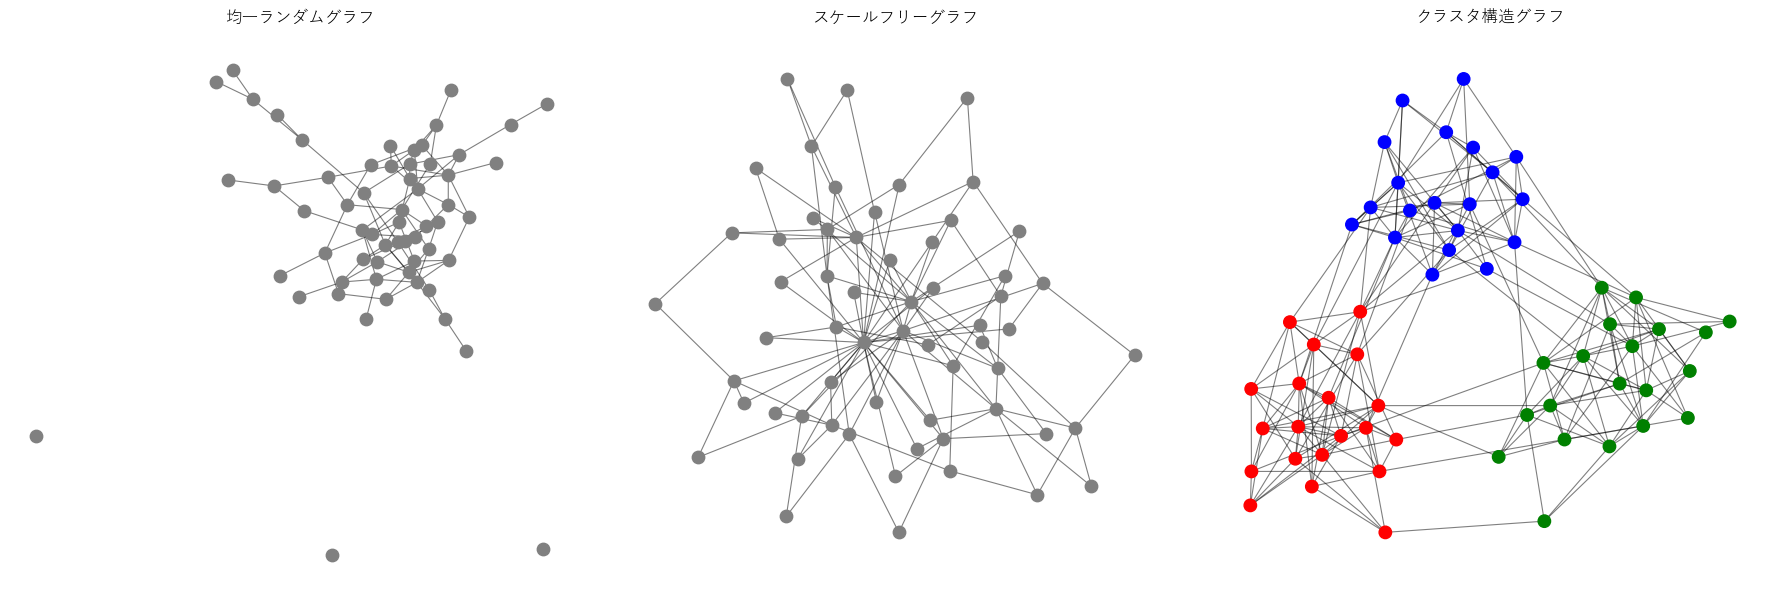

In [3]:
import matplotlib.pyplot as plt
import networkx as nx
import random
import matplotlib.font_manager as fm


# =========================
# 日本語フォント自動設定
# =========================
def set_japanese_font():
    font_candidates = [
        "Yu Gothic",
        "MS Gothic",
        "Hiragino Sans",
        "IPAPGothic"
    ]

    available_fonts = {f.name for f in fm.fontManager.ttflist}

    for font in font_candidates:
        if font in available_fonts:
            plt.rcParams["font.family"] = font
            print(f"[INFO] フォント設定: {font}")
            return

    print("[WARNING] 日本語フォントが見つかりません。英語表示にしてください。")


set_japanese_font()


# =========================
# 共通描画関数
# =========================
def draw_graph(ax, G, title, node_colors=None, seed=42):
    pos = nx.spring_layout(G, seed=seed)

    if node_colors is None:
        node_colors = "gray"

    nx.draw_networkx_nodes(G, pos, node_size=80, node_color=node_colors, ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.5, width=0.8, ax=ax)

    ax.set_title(title)
    ax.axis("off")


# =========================
# グラフ生成
# =========================
def make_uniform_random_graph(n=60, p=0.06, seed=42):
    return nx.erdos_renyi_graph(n=n, p=p, seed=seed)


def make_scale_free_graph(n=60, m=2, seed=42):
    return nx.barabasi_albert_graph(n=n, m=m, seed=seed)


def make_cluster_graph(
    cluster_sizes=(20, 20, 20),
    p_in=0.35,
    p_out=0.02,
    seed=42
):
    sizes = list(cluster_sizes)
    k = len(sizes)

    probs = []
    for i in range(k):
        row = []
        for j in range(k):
            row.append(p_in if i == j else p_out)
        probs.append(row)

    G = nx.stochastic_block_model(sizes, probs, seed=seed)

    # クラスタごとに色付け
    colors = []
    color_map = ["red", "blue", "green", "orange", "purple"]

    for i, size in enumerate(sizes):
        colors += [color_map[i % len(color_map)]] * size

    return G, colors


# =========================
# メイン処理
# =========================
def main():
    random.seed(42)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1. 均一ランダム
    G1 = make_uniform_random_graph()
    draw_graph(axes[0], G1, "均一ランダムグラフ")

    # 2. スケールフリー
    G2 = make_scale_free_graph()
    draw_graph(axes[1], G2, "スケールフリーグラフ")

    # 3. クラスタ構造
    G3, colors = make_cluster_graph()
    draw_graph(axes[2], G3, "クラスタ構造グラフ", node_colors=colors)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()